In [12]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path(r"c:\Users\yonat\OneDrive\Desktop\Nw File Anomaly Detection")

# Substance folders: (display_name, folder_name_pattern)
SUBSTANCE_FOLDERS = [
    ("Aceton", ["Aceton New", "Aceton Old"]),
    ("Redidlo", ["Redidlo New", "Redidlo Old"]),
    ("Softasept", ["Softasept New", "Softasept Old"]),
    ("Savo", ["Savo New", "Savo Old"]),
    ("Vinegar", ["Vinegar New", "Vinegar Old"]),
]

# Columns in dataBlock: [sensor_index, sensor_id, timestamp, rtc, temp, pressure, humidity, gas_resistance, heater_step_index, ...]
SENSOR_COL, STEP_COL, GR_COL, ERROR_COL = 0, 8, 7, 12
N_SENSORS, N_STEPS = 8, 10

In [22]:
def _load_normal_air_gr_from_bmerawdata(folder_path: Path) -> dict:
    """Load from .bmerawdata files."""
    gr_by_sensor_step = defaultdict(list)
    normal_files = list(folder_path.glob("Normal*.bmerawdata")) + list(folder_path.glob("Nomal*.bmerawdata"))
    for fpath in sorted(normal_files):
        try:
            with open(fpath, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except Exception as e:
            print(f"  [skip] {fpath.name}: {e}")
            continue
        data_block = data.get('rawDataBody', {}).get('dataBlock', [])
        for row in data_block:
            if len(row) < 13:
                continue
            sensor = row[SENSOR_COL]
            step = row[STEP_COL]
            gr = row[GR_COL]
            err = row[ERROR_COL] if len(row) > ERROR_COL else 0
            if gr > 0 and err == 0:
                gr_by_sensor_step[(sensor, step)].append(gr)
    return dict(gr_by_sensor_step)


def _load_normal_air_gr_from_csv(folder_path: Path) -> dict:
    """Load from CSV files (e.g. Aceton Old has only CSV, no .bmerawdata)."""
    gr_by_sensor_step = defaultdict(list)
    csv_files = list(folder_path.glob("Normal*.csv")) + list(folder_path.glob("Nomal*.csv"))
    for fpath in sorted(csv_files):
        try:
            df = pd.read_csv(fpath)
        except Exception as e:
            print(f"  [skip] {fpath.name}: {e}")
            continue
        # Columns: bme688_{sensor 1-8}_gas_res_step{1-10}  (1-based)
        for snum in range(1, 9):
            for step_num in range(1, 11):
                col = f"bme688_{snum}_gas_res_step{step_num}"
                if col not in df.columns:
                    continue
                vals = pd.to_numeric(df[col], errors='coerce').dropna()
                vals = vals[vals > 0]
                sensor = snum - 1  # 0-based
                step = step_num - 1  # 0-based
                gr_by_sensor_step[(sensor, step)].extend(vals.tolist())
    return dict(gr_by_sensor_step)


def load_normal_air_gr(folder_path: Path) -> dict:
    """
    Load Normal Air data from .bmerawdata or, if none found, from CSV.
    Returns: dict[(sensor, step)] -> list of gas resistance values.
    """
    gr = _load_normal_air_gr_from_bmerawdata(folder_path)
    if not gr or sum(len(v) for v in gr.values()) == 0:
        gr = _load_normal_air_gr_from_csv(folder_path)
    return gr

In [20]:
def compute_baseline_stats(gr_by_sensor_step: dict) -> pd.DataFrame:
    """
    Compute median, std, mean, count per (sensor, step).
    """
    rows = []
    for (sensor, step), vals in gr_by_sensor_step.items():
        arr = np.array(vals, dtype=float)
        rows.append({
            'sensor': sensor,
            'step': step,
            'median': np.median(arr),
            'mean': np.mean(arr),
            'std': np.std(arr),
            'count': len(arr),
            'min': np.min(arr),
            'max': np.max(arr),
        })
    return pd.DataFrame(rows)

In [15]:
calibration_results = {}  # {folder_name: {'gr_data': dict, 'baseline': DataFrame}}

for substance_name, folder_names in SUBSTANCE_FOLDERS:
    for folder_name in folder_names:
        folder_path = BASE_DIR / folder_name
        if not folder_path.exists():
            print(f"Folder not found: {folder_path}")
            continue
        
        gr_data = load_normal_air_gr(folder_path)
        baseline = compute_baseline_stats(gr_data)
        calibration_results[folder_name] = {'gr_data': gr_data, 'baseline': baseline}
        n_raw = list(folder_path.glob("Normal*.bmerawdata")) + list(folder_path.glob("Nomal*.bmerawdata"))
        n_csv = list(folder_path.glob("Normal*.csv")) + list(folder_path.glob("Nomal*.csv"))
        n_blocks = len(n_raw) if n_raw else len(n_csv)
        total_vals = sum(len(v) for v in gr_data.values())
        print(f"{folder_name}: {n_blocks} Normal files, {total_vals:,} GR values -> baseline for {len(baseline)} (sensor,step) pairs")

print("\nCalibration complete.")

Aceton New: 8 Normal files, 35,464 GR values -> baseline for 80 (sensor,step) pairs
Aceton Old: 6 Normal files, 26,538 GR values -> baseline for 80 (sensor,step) pairs
Redidlo New: 8 Normal files, 35,358 GR values -> baseline for 80 (sensor,step) pairs
Redidlo Old: 5 Normal files, 22,185 GR values -> baseline for 80 (sensor,step) pairs
Softasept New: 8 Normal files, 39,922 GR values -> baseline for 80 (sensor,step) pairs
Softasept Old: 4 Normal files, 13,977 GR values -> baseline for 80 (sensor,step) pairs
  [skip] Normal_1.bmerawdata: Expecting value: line 66440 column 1 (char 708390)
Savo New: 8 Normal files, 31,748 GR values -> baseline for 80 (sensor,step) pairs
Savo Old: 5 Normal files, 23,327 GR values -> baseline for 80 (sensor,step) pairs
  [skip] Normal_3.bmerawdata: Expecting value: line 90440 column 1 (char 967225)
Vinegar New: 8 Normal files, 30,547 GR values -> baseline for 80 (sensor,step) pairs
Vinegar Old: 6 Normal files, 26,716 GR values -> baseline for 80 (sensor,step

In [16]:
for substance_name, folder_names in SUBSTANCE_FOLDERS:
    new_name = f"{substance_name} New"
    old_name = f"{substance_name} Old"
    if new_name not in calibration_results or old_name not in calibration_results:
        continue
    
    df_new = calibration_results[new_name]['baseline']
    df_old = calibration_results[old_name]['baseline']
    
    # Merge on (sensor, step)
    merged = df_new.merge(df_old, on=['sensor','step'], suffixes=('_new','_old'))
    merged['median_diff_pct'] = 100 * (merged['median_new'] - merged['median_old']) / merged['median_old'].replace(0, np.nan)
    merged['std_diff'] = merged['std_new'] - merged['std_old']
    
    print(f"\n{'='*60}")
    print(f"{substance_name}: Old vs New calibration comparison")
    print(f"{'='*60}")
    print(f"Median diff % (New - Old) / Old:")
    print(merged[['sensor','step','median_new','median_old','median_diff_pct']].round(4).to_string(index=False))
    print(f"\nSummary: mean |median_diff_pct| = {merged['median_diff_pct'].abs().mean():.2f}%")
    print(f"         mean std_new = {merged['std_new'].mean():.2f}, mean std_old = {merged['std_old'].mean():.2f}")


Aceton: Old vs New calibration comparison
Median diff % (New - Old) / Old:
 sensor  step   median_new   median_old  median_diff_pct
      0     0  100136.9062   42482.5742         135.7129
      1     0  105393.3242   37847.9043         178.4654
      2     0  159228.7656   74278.3789         114.3676
      3     0   56952.1680   31964.0811          78.1755
      4     0   75128.4062   34538.5859         117.5202
      5     0   62683.6445   29999.4502         108.9493
      6     0   29287.3525   15717.0928          86.3408
      7     0   40050.0625   14538.8457         175.4693
      0     1 6590507.0000 1684220.7500         291.3090
      1     1 3233813.5000  862324.3750         275.0113
      2     1 7256030.0000 1797871.3750         303.5901
      3     1 3136294.0000 1098126.1875         185.6042
      4     1 3527235.1250  905193.3750         289.6665
      5     1 1562766.8750  493493.9688         216.6740
      6     1 1287645.3750  405785.6250         217.3216
      7     

In [17]:
# Old vs New correlation (how related is the calibration data?)
print("=" * 70)
print("OLD vs NEW: How related is the calibration data?")
print("=" * 70)

for substance_name, _ in SUBSTANCE_FOLDERS:
    new_name = f"{substance_name} New"
    old_name = f"{substance_name} Old"
    if new_name not in calibration_results or old_name not in calibration_results:
        continue
    df_new = calibration_results[new_name]['baseline']
    df_old = calibration_results[old_name]['baseline']
    merged = df_new.merge(df_old, on=['sensor', 'step'], suffixes=('_new', '_old'))
    if merged.empty:
        continue
    med_new = merged['median_new'].values
    med_old = merged['median_old'].values
    r_pearson = np.corrcoef(med_new, med_old)[0, 1]
    r_spearman = merged['median_new'].corr(merged['median_old'], method='spearman')
    pct_diff = 100 * (med_new - med_old) / (med_old + 1e-10)
    print(f"\n{substance_name}:")
    print(f"  Pearson r  = {r_pearson:.4f}  (linear correlation)")
    print(f"  Spearman r = {r_spearman:.4f}  (rank correlation)")
    print(f"  Median % diff (New-Old)/Old: mean={pct_diff.mean():.1f}%, median={np.median(pct_diff):.1f}%, |max|={np.abs(pct_diff).max():.1f}%")

OLD vs NEW: How related is the calibration data?

Aceton:
  Pearson r  = 0.9921  (linear correlation)
  Spearman r = 0.9900  (rank correlation)
  Median % diff (New-Old)/Old: mean=205.5%, median=195.2%, |max|=405.6%

Redidlo:
  Pearson r  = 0.9817  (linear correlation)
  Spearman r = 0.9953  (rank correlation)
  Median % diff (New-Old)/Old: mean=381.7%, median=385.4%, |max|=703.8%

Softasept:
  Pearson r  = 0.9874  (linear correlation)
  Spearman r = 0.9919  (rank correlation)
  Median % diff (New-Old)/Old: mean=200.4%, median=158.4%, |max|=415.3%

Savo:
  Pearson r  = 0.9790  (linear correlation)
  Spearman r = 0.9913  (rank correlation)
  Median % diff (New-Old)/Old: mean=138.0%, median=113.5%, |max|=339.4%

Vinegar:
  Pearson r  = 0.9880  (linear correlation)
  Spearman r = 0.9974  (rank correlation)
  Median % diff (New-Old)/Old: mean=84.8%, median=76.9%, |max|=154.0%


In [18]:
OUTPUT_DIR = BASE_DIR / "calibration_baselines"
OUTPUT_DIR.mkdir(exist_ok=True)

for folder_name, data in calibration_results.items():
    out_path = OUTPUT_DIR / f"baseline_{folder_name.replace(' ', '_')}.csv"
    data['baseline'].to_csv(out_path, index=False)
    print(f"Saved: {out_path.name}")

print(f"\nAll baselines saved to: {OUTPUT_DIR}")

Saved: baseline_Aceton_New.csv
Saved: baseline_Aceton_Old.csv
Saved: baseline_Redidlo_New.csv
Saved: baseline_Redidlo_Old.csv
Saved: baseline_Softasept_New.csv
Saved: baseline_Softasept_Old.csv
Saved: baseline_Savo_New.csv
Saved: baseline_Savo_Old.csv
Saved: baseline_Vinegar_New.csv
Saved: baseline_Vinegar_Old.csv

All baselines saved to: c:\Users\yonat\OneDrive\Desktop\Nw File Anomaly Detection\calibration_baselines


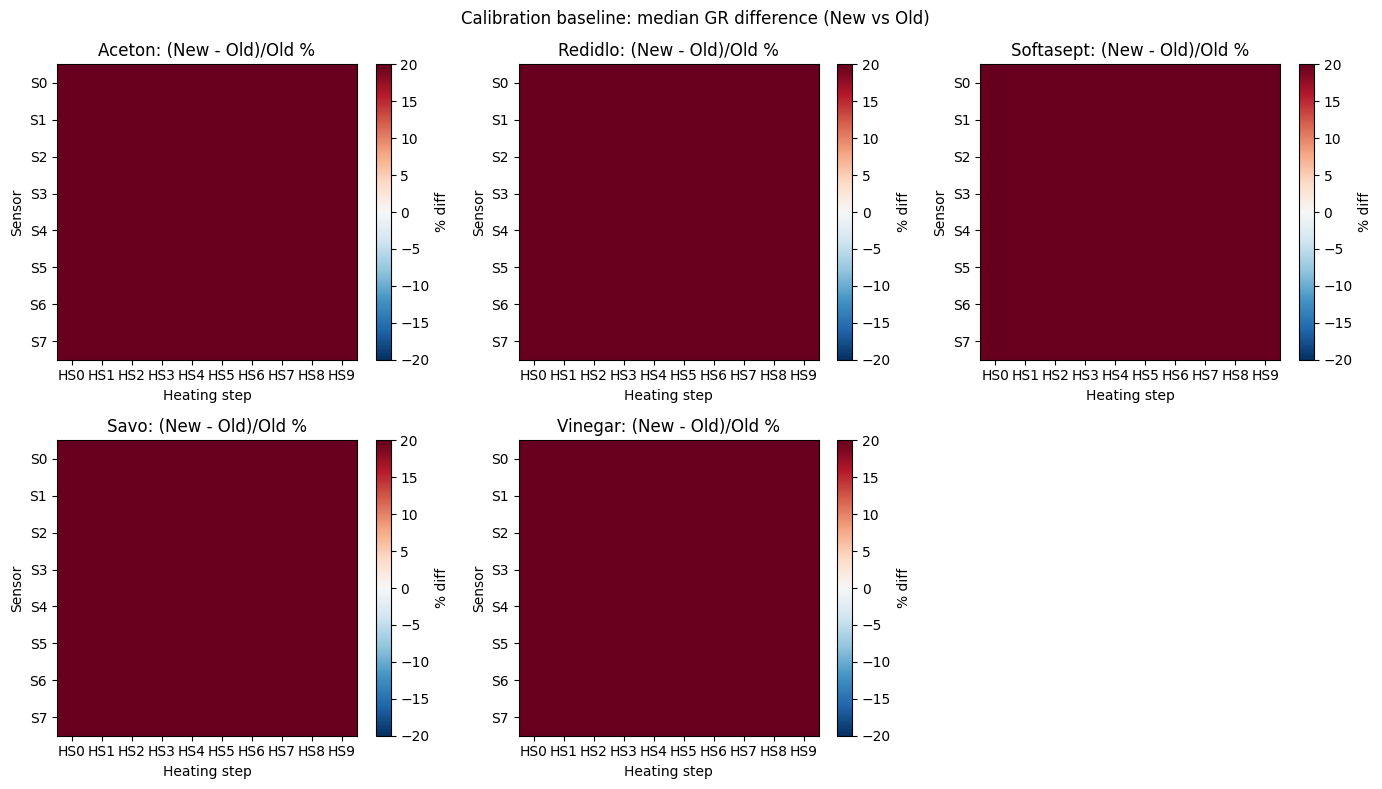

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (substance_name, folder_names) in enumerate(SUBSTANCE_FOLDERS):
    ax = axes[idx]
    new_name = f"{substance_name} New"
    old_name = f"{substance_name} Old"
    if new_name not in calibration_results or old_name not in calibration_results:
        ax.set_title(f"{substance_name}: missing data")
        continue
    
    df_new = calibration_results[new_name]['baseline'].pivot(index='sensor', columns='step', values='median')
    df_old = calibration_results[old_name]['baseline'].pivot(index='sensor', columns='step', values='median')
    
    diff_pct = 100 * (df_new - df_old) / df_old.replace(0, np.nan)
    im = ax.imshow(diff_pct.values, aspect='auto', cmap='RdBu_r', vmin=-20, vmax=20)
    ax.set_xticks(range(10))
    ax.set_xticklabels([f"HS{i}" for i in range(10)])
    ax.set_yticks(range(8))
    ax.set_yticklabels([f"S{i}" for i in range(8)])
    ax.set_xlabel('Heating step')
    ax.set_ylabel('Sensor')
    ax.set_title(f"{substance_name}: (New - Old)/Old %")
    plt.colorbar(im, ax=ax, label='% diff')

axes[-1].axis('off')
plt.suptitle('Calibration baseline: median GR difference (New vs Old)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration_comparison_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()